# Блок 7. Основы искусственного интеллекта и машинного обучения
## Занятие 8. Случайный лес — Random Forest

## Цель занятия

На прошлом занятии мы изучили дерево решений.

Сегодня изучаем более сильный алгоритм — **Random Forest**, или **случайный лес**.

Random Forest — это не одно дерево, а много деревьев решений, которые вместе принимают решение.

---

## Простая идея Random Forest

Одно дерево решений может ошибаться.

Но если построить много деревьев и попросить их проголосовать, итоговое решение часто становится надёжнее.

```text
Дерево 1 → класс 1
Дерево 2 → класс 1
Дерево 3 → класс 0
Дерево 4 → класс 1

Итог: класс 1
```

---

## Что такое ансамбль моделей

Ансамбль — это группа моделей, которые работают вместе.

Random Forest — пример ансамбля.

Преимущества:

- часто точнее одного дерева;
- устойчивее к переобучению;
- показывает важность признаков;
- хорошо работает на табличных данных.

---

## Что изучаем на занятии

- `RandomForestClassifier`;
- сравнение одного дерева и случайного леса;
- `n_estimators`;
- `max_depth`;
- важность признаков;
- метрики классификации;
- итоговый ML-отчёт.

---

## Датасет занятия

Используем встроенный датасет Breast Cancer из Scikit-Learn.

Задача: классифицировать объект по числовым признакам.

---

## Связь с дипломом

Random Forest можно использовать в проектах:

- HR: подходит кандидат или нет;
- медицина: риск заболевания;
- банк: надёжный или рискованный клиент;
- продажи: купит или не купит;
- маркетинг: отток клиентов;
- недвижимость: категория объекта.

---

## GitHub

```bash
git checkout main
git pull origin main
git checkout -b feature/block7-lesson08-random-forest

git add .
git commit -m "feat: add random forest lesson"
git push -u origin feature/block7-lesson08-random-forest
```

## Ячейка 1. Импорт библиотек

### Алгоритм

1. Импортируем `pandas` для таблиц.
2. Импортируем `matplotlib` для графиков.
3. Импортируем датасет Breast Cancer.
4. Импортируем модели:
   - DecisionTreeClassifier;
   - RandomForestClassifier.
5. Импортируем метрики качества.

Сегодня сравниваем одно дерево решений и случайный лес.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Библиотеки подключены")

assert pd is not None

Библиотеки подключены


## Ячейка 2. Загрузка датасета

### Алгоритм

1. Загружаем Breast Cancer.
2. Создаём `X` с признаками.
3. Создаём `y` с целевой переменной.
4. Проверяем размеры данных.

Это задача бинарной классификации.

In [12]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
print("Классы:", data.target_names)

display(X.head())

assert len(X) == len(y)
assert X.shape[1] > 10

Размер X: (569, 30)
Размер y: (569,)
Классы: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Ячейка 3. Разделение данных

### Алгоритм

1. Делим данные на train и test.
2. Используем `stratify=y`, чтобы сохранить баланс классов.
3. Проверяем размеры.

Для деревьев и случайного леса масштабирование признаков не обязательно.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

assert len(X_train) > len(X_test)

Train: (455, 30)
Test: (114, 30)


## Ячейка 4. Модель 1: одно дерево решений

### Алгоритм

1. Создаём `DecisionTreeClassifier`.
2. Ограничиваем глубину дерева.
3. Обучаем модель.
4. Получаем предсказания.
5. Считаем Accuracy.

Это базовая модель для сравнения.

Этот код обучает и оценивает базовую модель дерева решений (Decision Tree) для задачи классификации:

Создание модели (DecisionTreeClassifier): Инициализируется классификатор дерева решений. Параметр max_depth=3 ограничивает максимальную глубину дерева тремя уровнями (чтобы избежать переобучения), а random_state=42 фиксирует случайность для воспроизводимости результатов.

Обучение модели (.fit()): Метод tree_model.fit(X_train, y_train) обучает дерево решений на обучающей выборке (признаках X_train и соответствующих метках классов y_train).

Предсказание (.predict()): С помощью метода tree_model.predict(X_test) модель делает предсказания классов для тестовой выборки X_test.

Оценка качества (accuracy_score): Функция accuracy_score(y_test, tree_pred) рассчитывает долю правильных ответов (Accuracy), сравнивая предсказанные моделью значения с реальными метками y_test.

Вывод и проверка (assert): Значение точности выводится на экран, а инструкция assert tree_accuracy > 0.7 проверяет, что точность модели на тестовых данных превышает 70% (7.0).

In [14]:
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)

assert tree_accuracy > 0.7

Decision Tree Accuracy: 0.9385964912280702


## Ячейка 5. Модель 2: Random Forest

### Алгоритм

1. Создаём `RandomForestClassifier`.
2. Указываем количество деревьев `n_estimators=100`.
3. Ограничиваем глубину через `max_depth`.
4. Обучаем модель.
5. Получаем предсказания.
6. Считаем Accuracy.

Random Forest объединяет много деревьев.

код выполняет классический цикл работы с моделью машинного обучения:

Инициализирует модель DecisionTreeClassifier с ограничением по глубине до 3 уровней, чтобы дерево не переобучалось.
Обучает её на тренировочных данных (X_train, y_train) с помощью метода .fit().
Предсказывает классы для тестовых признаков (X_test) через метод .predict().
Оценивает долю правильных ответов (Accuracy) с помощью функции accuracy_score.
Проверяет с помощью assert, что точность модели на тестовой выборке получилась выше 70%.

In [15]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

forest_accuracy = accuracy_score(y_test, forest_pred)

print("Random Forest Accuracy:", forest_accuracy)

assert forest_accuracy > 0.8

Random Forest Accuracy: 0.956140350877193


## Ячейка 6. Сравнение метрик

### Алгоритм

1. Создаём функцию `calculate_metrics`.
2. Считаем Accuracy, Precision, Recall, F1.
3. Получаем отчёт для дерева.
4. Получаем отчёт для случайного леса.
5. Сравниваем результаты.

Так удобно сравнивать разные модели.

 код рассчитывает метрики качества для двух моделей (Дерева решений и Случайного леса) и объединяет их в одну удобную таблицу (DataFrame) для наглядного сравнения:

Расчёт метрик для дерева решений (tree_metrics): Строка tree_metrics = calculate_metrics(y_test, tree_pred) вызывает ранее созданную функцию calculate_metrics. Она сравнивает реальные ответы из тестовой выборки (y_test) с предсказаниями дерева решений (tree_pred) и возвращает словарь с метриками: accuracy, precision, recall и f1.

Расчёт метрик для случайного леса (forest_metrics): Аналогично, строка forest_metrics = calculate_metrics(y_test, forest_pred) рассчитывает те же четыре метрики для предсказаний случайного леса (forest_pred).

Создание общей таблицы (metrics_df): Конструкция pd.DataFrame([...]) преобразует список словарей в таблицу pandas.

Внутри списка находятся два словаря, созданных с использованием оператора распаковки **.
Выражение {"model": "Decision Tree", **tree_metrics} создаёт новый словарь, куда сначала записывается имя модели "model": "Decision Tree", а затем подставляются (распаковываются) все пары ключ-значение из словаря tree_metrics (например, "accuracy": 0.92, "precision": ... и т.д.).
То же самое происходит для Случайного леса.
В результате получается аккуратная таблица, где строки соответствуют моделям, а столбцы — их метрикам эффективности.



In [16]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }

tree_metrics = calculate_metrics(y_test, tree_pred)
forest_metrics = calculate_metrics(y_test, forest_pred)

metrics_df = pd.DataFrame([
    {"model": "Decision Tree", **tree_metrics},
    {"model": "Random Forest", **forest_metrics}
])

display(metrics_df)

assert metrics_df.shape[0] == 2
assert "accuracy" in metrics_df.columns

,model,accuracy,precision,recall,f1
0,Decision Tree,0.938596,0.945205,0.958333,0.951724
1,Random Forest,0.956140,0.958904,0.972222,0.965517


## Ячейка 7. Важность признаков Random Forest

### Алгоритм

1. Берём `feature_importances_` из модели.
2. Создаём таблицу с признаками и важностью.
3. Сортируем по важности.
4. Показываем TOP-10 признаков.

Это помогает объяснить, какие признаки сильнее влияют на решение модели.

In [17]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

display(feature_importance.head(10))

assert feature_importance["importance"].sum() > 0.99

,feature,importance
23,worst area,0.138294
27,worst concave points,0.132993
20,worst radius,0.100805
7,mean concave points,0.098489
22,worst perimeter,0.072224
2,mean perimeter,0.068612
0,mean radius,0.067465
6,mean concavity,0.057445
3,mean area,0.050615
26,worst concavity,0.031544


## Ячейка 8. Визуализация важности признаков

### Алгоритм

1. Берём TOP-10 признаков.
2. Строим горизонтальную столбчатую диаграмму.
3. Добавляем заголовок и сетку.
4. Интерпретируем результат.

Такой график хорошо подходит для дипломного отчёта.

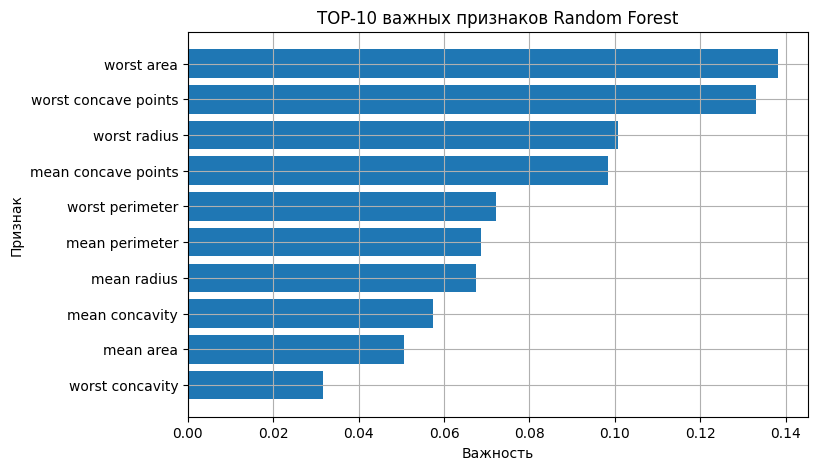

In [18]:
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(8, 5))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("TOP-10 важных признаков Random Forest")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.grid(True)
plt.show()

assert len(top_features) == 10

## Ячейка 9. Влияние количества деревьев

### Алгоритм

1. Создаём список разных значений `n_estimators`.
2. Для каждого значения обучаем Random Forest.
3. Считаем Accuracy.
4. Строим график зависимости качества от количества деревьев.

Так студент видит, что параметры модели влияют на качество.

,n_estimators,accuracy
0,5,0.938596
1,10,0.956140
2,30,0.956140
3,50,0.956140
4,100,0.956140
5,150,0.947368


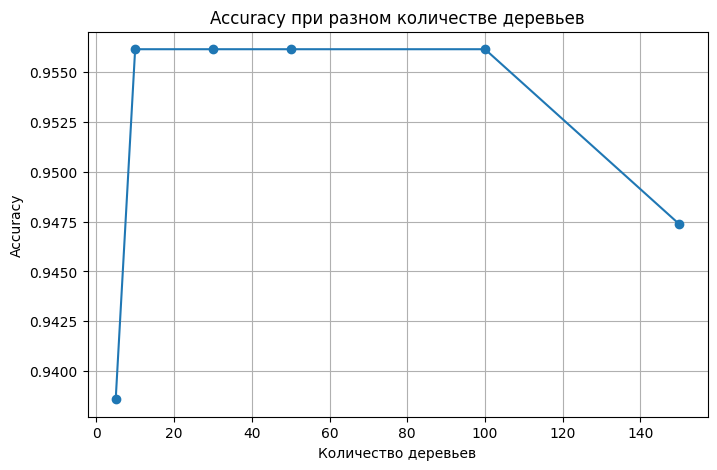

In [19]:
estimators_list = [5, 10, 30, 50, 100, 150]
scores = []

for n in estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=5,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    score = accuracy_score(y_test, pred)
    scores.append(score)

results_df = pd.DataFrame({
    "n_estimators": estimators_list,
    "accuracy": scores
})

display(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df["n_estimators"], results_df["accuracy"], marker="o")
plt.title("Accuracy при разном количестве деревьев")
plt.xlabel("Количество деревьев")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

assert len(scores) == len(estimators_list)

## Ячейка 10. Итоговый ML-отчёт

### Алгоритм

1. Находим лучшую модель по Accuracy.
2. Собираем итоговый словарь отчёта.
3. Добавляем метрики Random Forest.
4. Добавляем самый важный признак.
5. Формулируем выводы.

Это шаблон отчёта для дипломного проекта с классификацией.

In [20]:
best_model_name = "Random Forest" if forest_accuracy >= tree_accuracy else "Decision Tree"

final_report = {
    "rows": len(X),
    "features": X.shape[1],
    "best_model": best_model_name,
    "tree_accuracy": round(tree_accuracy, 4),
    "forest_accuracy": round(forest_accuracy, 4),
    "forest_f1": round(forest_metrics["f1"], 4),
    "top_feature": feature_importance.iloc[0]["feature"]
}

print("Итоговый отчёт:")
for key, value in final_report.items():
    print(key, ":", value)

conclusions = [
    "Random Forest объединяет несколько деревьев решений.",
    "Ансамбль часто работает устойчивее, чем одно дерево.",
    "Количество деревьев влияет на качество модели.",
    "Важность признаков помогает объяснять решения модели.",
    "Random Forest хорошо подходит для табличных данных и дипломных ML-проектов."
]

print()
print("Выводы:")
for item in conclusions:
    print("-", item)

assert final_report["features"] > 10
assert len(conclusions) == 5

Итоговый отчёт:
rows : 569
features : 30
best_model : Random Forest
tree_accuracy : 0.9386
forest_accuracy : 0.9561
forest_f1 : 0.9655
top_feature : worst area

Выводы:
- Random Forest объединяет несколько деревьев решений.
- Ансамбль часто работает устойчивее, чем одно дерево.
- Количество деревьев влияет на качество модели.
- Важность признаков помогает объяснять решения модели.
- Random Forest хорошо подходит для табличных данных и дипломных ML-проектов.


# Итог занятия 8

Сегодня вы изучили:

- Random Forest;
- ансамбль моделей;
- `n_estimators`;
- `max_depth`;
- сравнение Decision Tree и Random Forest;
- метрики классификации;
- важность признаков;
- влияние количества деревьев;
- итоговый ML-отчёт.

## Что показать преподавателю

- обученное дерево решений;
- обученный Random Forest;
- таблицу сравнения метрик;
- график важности признаков;
- график зависимости accuracy от количества деревьев;
- итоговые выводы.

## GitHub

```bash
git add .
git commit -m "feat: add random forest lesson"
git push -u origin feature/block7-lesson08-random-forest
```